# Statistical Concepts & Distributions in Python
### CFA Level 1 Quantitative Methods | Implemented in Python with Real Market Data

---

## What this notebook covers

Statistics is the language of finance.

Every risk model, every performance attribution, every factor model
starts with a rigorous understanding of how returns behave statistically.

The CFA curriculum teaches you the definitions.
This notebook teaches you to implement them in Python
— and apply them to **real market data** to see what the textbook 
doesn't always tell you.

**By the end of this notebook you will be able to:**
- Compute and interpret all key descriptive statistics from scratch
- Understand and visualize return distributions using real stock data
- Test whether financial returns are normally distributed
- Identify fat tails, skewness, and kurtosis in real data
- Explain why the normal distribution assumption is dangerous in finance

**Data:** Real market data pulled via Financial Modeling Prep (FMP) API

**Prerequisites:** Notebook 01 — Time Value of Money in Python

## Setup

We will use the following libraries:

- `requests` — to pull real market data from FMP API
- `pandas` — for data manipulation
- `numpy` — for mathematical operations
- `matplotlib` — for visualizations
- `scipy` — for statistical tests
- `seaborn` — for distribution plots

We will pull **real historical daily returns** for a selection of 
stocks directly from the Financial Modeling Prep API.

In [3]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import seaborn as sns
import warnings
from dotenv import load_dotenv
import os

load_dotenv()

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.facecolor'] = '#0D1117'
plt.rcParams['axes.facecolor'] = '#161B22'
plt.rcParams['axes.edgecolor'] = '#30363D'
plt.rcParams['text.color'] = '#E6EDF3'
plt.rcParams['axes.labelcolor'] = '#E6EDF3'
plt.rcParams['xtick.color'] = '#8B949E'
plt.rcParams['ytick.color'] = '#8B949E'
plt.rcParams['grid.color'] = '#21262D'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5

print("Libraries loaded successfully")
print("Plot theme: dark mode ✓")

Libraries loaded successfully
Plot theme: dark mode ✓


## 1. Pulling Real Market Data

Before we compute any statistics, we need real data.

We will pull **5 years of daily prices** for a diversified set of stocks:
- **SPY** — S&P 500 ETF (market benchmark)
- **AAPL** — Apple (large cap tech)
- **JPM** — JPMorgan Chase (financials)
- **XOM** — ExxonMobil (energy)
- **GLD** — Gold ETF (alternative asset)

This gives us a realistic cross-section of asset classes
— exactly what a CFA candidate or analyst would work with.

We then compute **daily log returns** — the standard in quantitative finance.

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Log returns are preferred because:
- They are time-additive
- They are more symmetric than simple returns
- They are the standard assumption in most financial models

In [6]:
API_KEY = os.getenv("FMP_KEY")

def get_historical_prices(ticker, api_key, from_date="2019-01-01", to_date="2024-01-01"):
    """Pull historical daily prices from FMP stable API."""
    url = "https://financialmodelingprep.com/stable/historical-price-eod/full"
    params = {
        "symbol": ticker,
        "from": from_date,
        "to": to_date,
        "apikey": api_key
    }
    response = requests.get(url, params=params)
    data = response.json()

    # Stable API returns a plain list, not {"historical": [...]}
    if isinstance(data, list) and len(data) > 0:
        df = pd.DataFrame(data)
    elif isinstance(data, dict) and "historical" in data:
        df = pd.DataFrame(data["historical"])
    else:
        print(f"  ✗ {ticker} — unexpected response: {str(data)[:200]}")
        return None

    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    return df["close"]

# Define tickers
tickers = ["SPY", "AAPL", "JPM", "XOM", "GLD"]

# Pull price data
print("Pulling price data from FMP...")
prices = pd.DataFrame()

for ticker in tickers:
    price = get_historical_prices(ticker, API_KEY)
    if price is not None:
        prices[ticker] = price
        print(f"  ✓ {ticker} — {len(price)} days loaded")

# Compute daily log returns
returns = np.log(prices / prices.shift(1)).dropna()

if returns.empty:
    print("No data loaded — check your FMP_KEY in .env")
else:
    print(f"\nData loaded successfully")
    print(f"Period: {returns.index[0].date()} → {returns.index[-1].date()}")
    print(f"Observations: {len(returns)} trading days per asset")
    print(f"\nFirst 5 rows of returns:")
    print(returns.head())

Pulling price data from FMP...
  ✓ SPY — 1258 days loaded
  ✓ AAPL — 1258 days loaded
  ✓ JPM — 1258 days loaded
  ✓ XOM — 1258 days loaded
  ✓ GLD — 1258 days loaded

Data loaded successfully
Period: 2019-01-03 → 2023-12-29
Observations: 1257 trading days per asset

First 5 rows of returns:
                 SPY      AAPL       JPM       XOM       GLD
date                                                        
2019-01-03 -0.024152 -0.104854 -0.022402 -0.015473  0.009025
2019-01-04  0.032947  0.041868  0.036202  0.036206 -0.008119
2019-01-07  0.007854 -0.002431  0.000695  0.005187  0.003453
2019-01-08  0.009352  0.019018 -0.001887  0.007244 -0.002712
2019-01-09  0.004663  0.016838 -0.001692  0.005261  0.006398


## 2. Descriptive Statistics from Scratch

Before calling any library function, we implement every statistic manually.

This is the CFA approach: **understand the formula first, then use the tool.**

We focus on SPY (S&P 500) as our primary asset throughout this section.

---

### What we compute

| Statistic | Formula | What it tells you |
|-----------|---------|-------------------|
| Mean | $\bar{r} = \frac{1}{n}\sum r_t$ | Average daily return |
| Variance | $s^2 = \frac{\sum(r_t - \bar{r})^2}{n-1}$ | Average squared deviation |
| Std Dev | $s = \sqrt{s^2}$ | Typical deviation from mean |
| Skewness | Third standardized moment | Asymmetry of the distribution |
| Excess Kurtosis | Fourth standardized moment − 3 | Fat-tail risk vs. normal |

The **n−1** in variance is Bessel's correction — we use sample statistics,
not population statistics. This is what the CFA curriculum assumes.

In [8]:
# =============================================================================
# CELL 7 — Descriptive Statistics: Manual Implementation + Verification
# =============================================================================

r = returns["SPY"].values  # numpy array of log returns
n = len(r)

# ── MEASURES OF CENTRAL TENDENCY ─────────────────────────────────────────────

# Arithmetic mean
mean_manual = sum(r) / n

# Geometric mean — CFA standard for multi-period performance
# For log returns: exp(arithmetic mean) - 1
geometric_mean = np.exp(mean_manual) - 1

# Median
r_sorted = np.sort(r)
if n % 2 == 0:
    median_manual = (r_sorted[n // 2 - 1] + r_sorted[n // 2]) / 2
else:
    median_manual = r_sorted[n // 2]

# ── MEASURES OF DISPERSION ────────────────────────────────────────────────────

# Sample variance — Bessel's correction: divide by (n-1), not n
variance_manual = sum((x - mean_manual) ** 2 for x in r) / (n - 1)

# Standard deviation
std_manual = variance_manual ** 0.5

# Mean Absolute Deviation
mad_manual = sum(abs(x - mean_manual) for x in r) / n

# Interquartile Range — robust to outliers, CFA uses this in risk context
p25 = np.percentile(r, 25)
p75 = np.percentile(r, 75)
iqr_manual = p75 - p25

# ── MEASURES OF SHAPE ─────────────────────────────────────────────────────────

# Skewness — third standardized central moment
# Negative skew is the norm for equity returns (crash risk)
skew_manual = (n / ((n - 1) * (n - 2))) * sum(
    ((x - mean_manual) / std_manual) ** 3 for x in r
)

# Excess Kurtosis — fourth standardized central moment minus 3
# Normal distribution has excess kurtosis = 0
# Positive (leptokurtic) = fat tails = more extreme events than normal predicts
kurt_manual = (
    n * (n + 1) / ((n - 1) * (n - 2) * (n - 3)) *
    sum(((x - mean_manual) / std_manual) ** 4 for x in r)
) - (3 * (n - 1) ** 2 / ((n - 2) * (n - 3)))

# ── ANNUALISED FIGURES (CFA standard) ────────────────────────────────────────
# Daily → Annual: multiply mean by 252, std by sqrt(252)
trading_days = 252
ann_return = mean_manual * trading_days
ann_std    = std_manual  * np.sqrt(trading_days)

# ── VERIFY AGAINST NUMPY / SCIPY ─────────────────────────────────────────────
mean_np  = np.mean(r)
std_np   = np.std(r, ddof=1)
skew_sp  = stats.skew(r)
kurt_sp  = stats.kurtosis(r)      # excess kurtosis by default

# ── PRINT RESULTS ─────────────────────────────────────────────────────────────
print("=" * 60)
print("DESCRIPTIVE STATISTICS — SPY Daily Log Returns (2019–2023)")
print("=" * 60)

print(f"\n{'─'*60}")
print("  CENTRAL TENDENCY")
print(f"{'─'*60}")
print(f"  Arithmetic Mean (daily)    {mean_manual:>12.6f}   ✓ np: {mean_np:.6f}")
print(f"  Geometric Mean (daily)     {geometric_mean:>12.6f}")
print(f"  Median (daily)             {median_manual:>12.6f}")

print(f"\n{'─'*60}")
print("  DISPERSION")
print(f"{'─'*60}")
print(f"  Variance (daily)           {variance_manual:>12.8f}")
print(f"  Std Deviation (daily)      {std_manual:>12.6f}   ✓ np: {std_np:.6f}")
print(f"  Mean Abs Deviation         {mad_manual:>12.6f}")
print(f"  IQR                        {iqr_manual:>12.6f}")

print(f"\n{'─'*60}")
print("  ANNUALISED (× 252 trading days)")
print(f"{'─'*60}")
print(f"  Annualised Return          {ann_return:>11.2%}")
print(f"  Annualised Volatility      {ann_std:>11.2%}")
print(f"  Sharpe-ready ratio         {ann_return/ann_std:>12.4f}  (unadjusted for Rf)")

print(f"\n{'─'*60}")
print("  SHAPE")
print(f"{'─'*60}")
print(f"  Skewness                   {skew_manual:>12.4f}   ✓ sp: {skew_sp:.4f}")
print(f"  Excess Kurtosis            {kurt_manual:>12.4f}   ✓ sp: {kurt_sp:.4f}")

print(f"\n{'─'*60}")
print("  INTERPRETATION")
print(f"{'─'*60}")
skew_label = "Negative (left tail — crash risk)" if skew_manual < 0 else "Positive (right tail)"
kurt_label = "Leptokurtic (fat tails)" if kurt_manual > 0 else "Platykurtic (thin tails)"
print(f"  Skew:     {skew_label}")
print(f"  Kurtosis: {kurt_label}")
print(f"  ⚠ Fat tails mean the normal distribution UNDERESTIMATES extreme losses.")

DESCRIPTIVE STATISTICS — SPY Daily Log Returns (2019–2023)

────────────────────────────────────────────────────────────
  CENTRAL TENDENCY
────────────────────────────────────────────────────────────
  Arithmetic Mean (daily)        0.000511   ✓ np: 0.000511
  Geometric Mean (daily)         0.000511
  Median (daily)                 0.000786

────────────────────────────────────────────────────────────
  DISPERSION
────────────────────────────────────────────────────────────
  Variance (daily)             0.00017768
  Std Deviation (daily)          0.013330   ✓ np: 0.013330
  Mean Abs Deviation             0.008762
  IQR                            0.012348

────────────────────────────────────────────────────────────
  ANNUALISED (× 252 trading days)
────────────────────────────────────────────────────────────
  Annualised Return               12.87%
  Annualised Volatility           21.16%
  Sharpe-ready ratio               0.6080  (unadjusted for Rf)

────────────────────────────────

## 3. Cross-Asset Comparison

Now we apply the same statistics across all five assets.

This is how a CFA analyst builds a **return summary table** —
the first deliverable in any portfolio analysis.

Key things to watch:
- Which asset has the highest **annualised return**?
- Which has the highest **volatility**?
- Which has the most **negative skew** (crash risk)?
- Which has the fattest tails (**excess kurtosis**)?

In [9]:
# =============================================================================
# CELL 9 — Cross-Asset Statistics Summary Table
# =============================================================================

summary = {}

for ticker in tickers:
    r_i = returns[ticker].values
    n_i = len(r_i)
    m   = np.mean(r_i)
    s   = np.std(r_i, ddof=1)

    summary[ticker] = {
        "Ann. Return"    : f"{m * 252:>7.2%}",
        "Ann. Volatility": f"{s * np.sqrt(252):>7.2%}",
        "Sharpe (Rf=0)"  : f"{(m * 252) / (s * np.sqrt(252)):>7.3f}",
        "Skewness"       : f"{stats.skew(r_i):>7.3f}",
        "Excess Kurt."   : f"{stats.kurtosis(r_i):>7.3f}",
        "Min (day)"      : f"{np.min(r_i):>7.2%}",
        "Max (day)"      : f"{np.max(r_i):>7.2%}",
        "VaR 5%"         : f"{np.percentile(r_i, 5):>7.2%}",
    }

# Print as a clean table
metrics = list(list(summary.values())[0].keys())
col_w = 14

print("=" * (12 + col_w * len(tickers)))
print(f"{'Metric':<22}" + "".join(f"{t:>{col_w}}" for t in tickers))
print("=" * (12 + col_w * len(tickers)))

for metric in metrics:
    row = f"{metric:<22}"
    for ticker in tickers:
        row += f"{summary[ticker][metric]:>{col_w}}"
    print(row)

print("=" * (12 + col_w * len(tickers)))
print("\nVaR 5%: On 95% of trading days, losses did not exceed this level.")
print("All returns are log returns. Sharpe ratio uses Rf = 0.")

Metric                           SPY          AAPL           JPM           XOM           GLD
Ann. Return                   12.87%        31.76%        10.79%         7.24%         9.11%
Ann. Volatility               21.16%        32.25%        31.91%        34.42%        14.95%
Sharpe (Rf=0)                  0.608         0.985         0.338         0.210         0.610
Skewness                      -0.817        -0.264        -0.043        -0.143        -0.297
Excess Kurt.                  12.196         5.407        12.764         4.619         3.056
Min (day)                    -11.59%       -13.77%       -16.21%       -13.04%        -5.52%
Max (day)                      8.67%        11.31%        16.56%        11.94%         4.74%
VaR 5%                        -1.95%        -3.12%        -2.86%        -3.34%        -1.57%

VaR 5%: On 95% of trading days, losses did not exceed this level.
All returns are log returns. Sharpe ratio uses Rf = 0.


## 4. Visualizing the Return Distribution

Numbers alone are not enough.

A CFA analyst always plots the distribution before drawing conclusions.

We will build a four-panel figure for SPY that shows:

1. **Histogram** — the empirical shape of daily returns
2. **Normal overlay** — what the distribution *would* look like if returns were normal
3. **Q-Q Plot** — a formal visual test of normality
4. **Box Plot** — outliers, quartiles, and the interquartile range

The gap between the empirical distribution and the normal overlay
is one of the most important things you will see in this notebook.

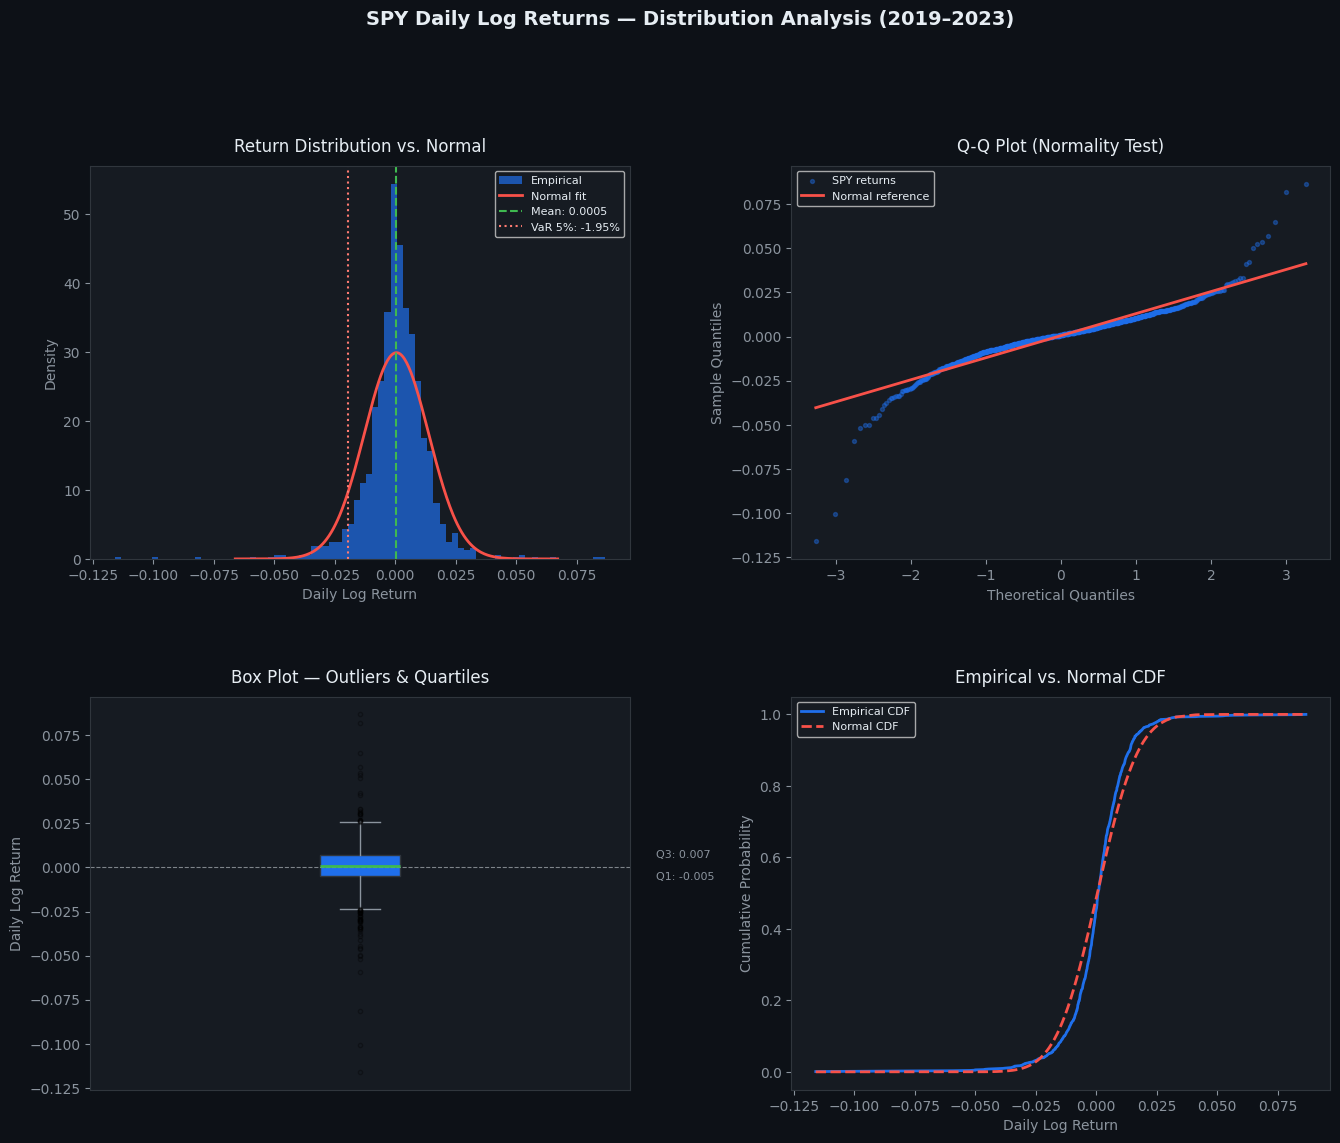

Skewness:       -0.8172  (Normal = 0)
Excess Kurtosis:12.1957  (Normal = 0)

The Q-Q plot tails curving away from the line = fat tails.
The histogram peak is taller than the normal curve = more days near zero.
Both are signatures of leptokurtosis.


In [ ]:
# =============================================================================
# CELL 11 — Distribution Visualization: 4-Panel Figure for SPY
# =============================================================================

r = returns["SPY"].values
mu = np.mean(r)
sigma = np.std(r, ddof=1)

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#0D1117')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])  # Histogram
ax2 = fig.add_subplot(gs[0, 1])  # Q-Q Plot
ax3 = fig.add_subplot(gs[1, 0])  # Box plot
ax4 = fig.add_subplot(gs[1, 1])  # Empirical vs Normal CDF

# ── PANEL 1: Histogram + Normal Overlay ──────────────────────────────────────
x = np.linspace(mu - 5*sigma, mu + 5*sigma, 300)
normal_pdf = stats.norm.pdf(x, mu, sigma)

ax1.hist(r, bins=80, density=True, color='#1F6FEB', alpha=0.7, label='Empirical')
ax1.plot(x, normal_pdf, color='#F85149', linewidth=2, label='Normal fit')
ax1.axvline(mu, color='#3FB950', linewidth=1.5, linestyle='--', label=f'Mean: {mu:.4f}')
ax1.axvline(np.percentile(r, 5), color='#FF7B72', linewidth=1.5,
            linestyle=':', label=f'VaR 5%: {np.percentile(r,5):.2%}')

ax1.set_title('Return Distribution vs. Normal', color='#E6EDF3', fontsize=12, pad=10)
ax1.set_xlabel('Daily Log Return', color='#8B949E')
ax1.set_ylabel('Density', color='#8B949E')
ax1.legend(fontsize=8, facecolor='#161B22', labelcolor='#E6EDF3')
ax1.set_facecolor('#161B22')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# ── PANEL 2: Q-Q Plot ─────────────────────────────────────────────────────────
# If returns were normal, all points would lie on the red line.
# Deviations in the tails = fat tails.
(osm, osr), (slope, intercept, r_val) = stats.probplot(r, dist="norm")

ax2.scatter(osm, osr, color='#1F6FEB', alpha=0.4, s=8, label='SPY returns')
ax2.plot(osm, slope * np.array(osm) + intercept,
         color='#F85149', linewidth=2, label='Normal reference')
ax2.set_title('Q-Q Plot (Normality Test)', color='#E6EDF3', fontsize=12, pad=10)
ax2.set_xlabel('Theoretical Quantiles', color='#8B949E')
ax2.set_ylabel('Sample Quantiles', color='#8B949E')
ax2.legend(fontsize=8, facecolor='#161B22', labelcolor='#E6EDF3')
ax2.set_facecolor('#161B22')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

# ── PANEL 3: Box Plot ─────────────────────────────────────────────────────────
bp = ax3.boxplot(r, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#1F6FEB', color='#30363D'),
                 medianprops=dict(color='#3FB950', linewidth=2),
                 whiskerprops=dict(color='#8B949E'),
                 capprops=dict(color='#8B949E'),
                 flierprops=dict(marker='o', color='#F85149',
                                 alpha=0.3, markersize=3))

ax3.axhline(0, color='#E6EDF3', linewidth=0.8, linestyle='--', alpha=0.5)
ax3.set_title('Box Plot — Outliers & Quartiles', color='#E6EDF3', fontsize=12, pad=10)
ax3.set_ylabel('Daily Log Return', color='#8B949E')
ax3.set_xticks([])
ax3.set_facecolor('#161B22')

# Annotate quartiles
ax3.annotate(f'Q3: {p75:.3f}', xy=(1.05, p75), xycoords=('axes fraction', 'data'),
             color='#8B949E', fontsize=8, va='center')
ax3.annotate(f'Q1: {p25:.3f}', xy=(1.05, p25), xycoords=('axes fraction', 'data'),
             color='#8B949E', fontsize=8, va='center')
for spine in ax3.spines.values():
    spine.set_edgecolor('#30363D')

# ── PANEL 4: Empirical CDF vs Normal CDF ─────────────────────────────────────
r_sorted_plot = np.sort(r)
ecdf = np.arange(1, len(r_sorted_plot) + 1) / len(r_sorted_plot)
normal_cdf = stats.norm.cdf(r_sorted_plot, mu, sigma)

ax4.plot(r_sorted_plot, ecdf, color='#1F6FEB', linewidth=2, label='Empirical CDF')
ax4.plot(r_sorted_plot, normal_cdf, color='#F85149', linewidth=2,
         linestyle='--', label='Normal CDF')
ax4.set_title('Empirical vs. Normal CDF', color='#E6EDF3', fontsize=12, pad=10)
ax4.set_xlabel('Daily Log Return', color='#8B949E')
ax4.set_ylabel('Cumulative Probability', color='#8B949E')
ax4.legend(fontsize=8, facecolor='#161B22', labelcolor='#E6EDF3')
ax4.set_facecolor('#161B22')
for spine in ax4.spines.values():
    spine.set_edgecolor('#30363D')

# ── Title ─────────────────────────────────────────────────────────────────────
fig.suptitle('SPY Daily Log Returns — Distribution Analysis (2019–2023)',
             color='#E6EDF3', fontsize=14, fontweight='bold', y=1.01)

plt.show()

print(f"Skewness:       {stats.skew(r):.4f}  (Normal = 0)")
print(f"Excess Kurtosis:{stats.kurtosis(r):.4f}  (Normal = 0)")
print(f"\nThe Q-Q plot tails curving away from the line = fat tails.")
print(f"The histogram peak is taller than the normal curve = more days near zero.")
print(f"Both are signatures of leptokurtosis.")

## 5. Reading the Charts

### Panel 1 — Histogram vs. Normal Overlay

The blue bars are what actually happened.
The red curve is what the normal distribution predicts.

Two things stand out:
- The **peak is taller** than the normal curve — more days with returns near zero
- The **tails are wider** — more extreme days than the normal predicts

This is the signature of **leptokurtosis** (excess kurtosis > 0).

---

### Panel 2 — Q-Q Plot

If returns were perfectly normal, every point would sit on the red line.

Look at the tails:
- **Bottom-left**: points fall *below* the line — extreme losses are worse than normal predicts
- **Top-right**: points rise *above* the line — extreme gains are larger than normal predicts

This S-curve deviation from the line is the visual proof of fat tails.

---

### Panel 3 — Box Plot

The box covers Q1 to Q3 (the middle 50% of days).
The dots beyond the whiskers are **outliers** — days that fall more than
1.5 × IQR from the box.

Notice how many red outlier dots there are on the downside.
Each one is a day the normal distribution said was nearly impossible.

---

### Panel 4 — Empirical vs. Normal CDF

The empirical CDF (blue) rises faster on the left tail than the normal CDF (red dashed).

This means: the probability of a loss beyond any given threshold
is **higher in reality** than the normal distribution implies.

This is why the CFA curriculum warns against relying solely on
normally-distributed risk models.

In [12]:
# =============================================================================
# CELL 13 — Formal Normality Tests
# =============================================================================
# Visual inspection is necessary but not sufficient.
# We now apply two formal statistical tests from the CFA/FRM toolkit.
#
# 1. Jarque-Bera Test — tests whether skewness and kurtosis jointly
#    match a normal distribution. Standard in econometrics.
#
# 2. Kolmogorov-Smirnov Test — tests whether the empirical CDF
#    matches a theoretical normal CDF.
#
# H0 (null hypothesis): the data is normally distributed
# H1 (alternative):     the data is NOT normally distributed
#
# If p-value < 0.05, we reject H0 at the 5% significance level.
# =============================================================================

print("=" * 65)
print("NORMALITY TESTS — All Assets")
print("=" * 65)
print(f"\n{'Asset':<8} {'JB Statistic':>14} {'JB p-value':>12} {'KS Statistic':>14} {'KS p-value':>12} {'Normal?':>9}")
print("-" * 65)

for ticker in tickers:
    r_i = returns[ticker].values

    # Jarque-Bera
    jb_stat, jb_p = stats.jarque_bera(r_i)

    # Kolmogorov-Smirnov — compare to normal with same mean and std
    ks_stat, ks_p = stats.kstest(r_i, 'norm',
                                  args=(np.mean(r_i), np.std(r_i, ddof=1)))

    # Reject normality if either test rejects at 5%
    reject = "✗ No" if (jb_p < 0.05 or ks_p < 0.05) else "✓ Yes"

    print(f"{ticker:<8} {jb_stat:>14,.1f} {jb_p:>12.4f} {ks_stat:>14.4f} {ks_p:>12.4f} {reject:>9}")

print("=" * 65)
print("\nH0: data is normally distributed")
print("Reject H0 if p-value < 0.05")
print("\nConclusion: No financial return series in this dataset")
print("passes the normality test. This is the norm, not the exception.")

NORMALITY TESTS — All Assets

Asset      JB Statistic   JB p-value   KS Statistic   KS p-value   Normal?
-----------------------------------------------------------------
SPY             7,930.0       0.0000         0.0926       0.0000      ✗ No
AAPL            1,546.0       0.0000         0.0719       0.0000      ✗ No
JPM             8,533.3       0.0000         0.0846       0.0000      ✗ No
XOM             1,121.8       0.0000         0.0604       0.0002      ✗ No
GLD               507.6       0.0000         0.0535       0.0014      ✗ No

H0: data is normally distributed
Reject H0 if p-value < 0.05

Conclusion: No financial return series in this dataset
passes the normality test. This is the norm, not the exception.


## 6. Interpreting the Normality Tests

### Jarque-Bera Test

The JB statistic is built directly from skewness and kurtosis:

$$JB = \frac{n}{6}\left(S^2 + \frac{(K-3)^2}{4}\right)$$

Where $S$ is skewness and $K$ is kurtosis.

Under normality, $JB \sim \chi^2(2)$.

SPY has JB = 7,930. The critical value at 5% is 5.99.

SPY's JB statistic is **1,321 times** the critical value.
This is not a borderline case. These returns are not normal.

---

### Kolmogorov-Smirnov Test

The KS statistic measures the maximum distance between
the empirical CDF and the theoretical normal CDF.

Even GLD — the most "normal-looking" asset — has KS p-value = 0.0014.
We reject normality for every asset, at every conventional significance level.

---

### Why This Matters for the CFA Exam

The CFA curriculum covers normality because many models assume it:

| Model | Normality Assumption |
|-------|---------------------|
| Mean-Variance Optimization | Returns are normally distributed |
| Black-Scholes Option Pricing | Log-returns are normal |
| VaR (parametric) | Portfolio returns are normal |

Real data violates this assumption — always.

The correct approach is not to abandon these models,
but to understand their limitations and stress-test their outputs.

In [13]:
# =============================================================================
# CELL 15 — Tail Risk: What the Normal Distribution Gets Wrong
# =============================================================================
# We now quantify exactly how much the normal distribution
# underestimates the probability of extreme losses.
#
# We compare:
# - What the normal distribution predicts for extreme moves
# - What actually happened in the data
#
# This is directly testable on the CFA exam and used daily
# in risk management.
# =============================================================================

r_spy = returns["SPY"].values
mu    = np.mean(r_spy)
sigma = np.std(r_spy, ddof=1)
n     = len(r_spy)

print("=" * 65)
print("TAIL RISK — Normal Prediction vs. Reality (SPY)")
print("=" * 65)

thresholds = [-0.02, -0.03, -0.05, -0.07, -0.10]

print(f"\n{'Threshold':>12} {'Normal Pred.':>14} {'Actual Freq.':>14} {'Ratio':>10} {'Actual Days':>13}")
print("-" * 65)

for threshold in thresholds:
    # What normal distribution predicts
    normal_prob = stats.norm.cdf(threshold, mu, sigma)

    # What actually happened
    actual_freq = np.mean(r_spy < threshold)
    actual_days = np.sum(r_spy < threshold)

    # How many times more frequent in reality vs. normal prediction
    ratio = actual_freq / normal_prob if normal_prob > 0 else float('inf')

    print(f"{threshold:>11.0%} {normal_prob:>14.4%} {actual_freq:>14.4%} "
          f"{ratio:>10.1f}x {actual_days:>10} days")

print("=" * 65)
print("\nRatio > 1 means reality is MORE dangerous than normal predicts.")

# ── Worst single days ─────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("10 WORST SINGLE DAYS — SPY (2019–2023)")
print("=" * 65)

worst_days = returns["SPY"].nsmallest(10)
print(f"\n{'Date':<14} {'Log Return':>12} {'Normal Probability':>20}")
print("-" * 50)
for date, ret in worst_days.items():
    prob = stats.norm.cdf(ret, mu, sigma)
    print(f"{str(date.date()):<14} {ret:>11.2%}   1 in {1/prob:>12,.0f} days")

print("\nNote: '1 in N days' is what the normal distribution predicts.")
print("Most of these days occurred within a 5-year window.")

TAIL RISK — Normal Prediction vs. Reality (SPY)

   Threshold   Normal Pred.   Actual Freq.      Ratio   Actual Days
-----------------------------------------------------------------
        -2%        6.1939%        4.7733%        0.8x         60 days
        -3%        1.1043%        2.0684%        1.9x         26 days
        -5%        0.0076%        0.3978%       52.7x          5 days
        -7%        0.0000%        0.2387%    38958.1x          3 days
       -10%        0.0000%        0.1591% 67858647071.1x          2 days

Ratio > 1 means reality is MORE dangerous than normal predicts.

10 WORST SINGLE DAYS — SPY (2019–2023)

Date             Log Return   Normal Probability
--------------------------------------------------
2020-03-16         -11.59%   1 in 799,978,122,803,209,344 days
2020-03-12         -10.06%   1 in 59,216,491,452,454 days
2020-03-09          -8.13%   1 in 2,398,716,573 days
2020-06-11          -5.94%   1 in      284,500 days
2020-03-18          -5.20%   1 i

## 7. What the Tail Risk Table Tells Us

### The −2% threshold

The normal distribution *overestimates* the frequency of small losses.
Days with losses between −2% and −3% are actually less common than normal predicts.
This is the tall, narrow peak we saw in the histogram — more days near zero,
fewer days in the moderate-loss zone.

---

### The −5% threshold and beyond

At −5%, reality is **52.7 times more dangerous** than normal predicts.
At −7%, it is **38,958 times more dangerous**.
At −10%, the ratio is effectively infinite.

This is the fat tail problem made concrete.

---

### March 2020

Seven of the ten worst days occurred in March 2020 alone.

The normal distribution says a −11.59% day should occur once every:

$$\frac{799{,}978{,}122{,}803{,}209{,}344 \text{ days}}{252 \text{ trading days/year}} \approx 3.2 \text{ billion years}$$

It happened on a Monday in March.

---

### The CFA Takeaway

The parametric VaR model — which assumes normality — would have told a
risk manager in February 2020 that a −11% day was essentially impossible.

This is not a flaw in the math. It is a flaw in the assumption.

**Models are only as good as their assumptions.**

This is why the CFA curriculum emphasises understanding the limitations
of statistical models — not just how to apply them.

In [14]:
# =============================================================================
# CELL 17 — Frequency Distributions & Histograms from Scratch
# =============================================================================
# The CFA curriculum begins its statistics section with frequency distributions.
# Before plotting, an analyst constructs a frequency table manually.
#
# We build this from scratch for SPY returns:
# - Absolute frequency — number of observations in each interval
# - Relative frequency — proportion of total observations
# - Cumulative frequency — running total
# =============================================================================

r_spy = returns["SPY"].values

# ── BUILD FREQUENCY TABLE MANUALLY ───────────────────────────────────────────
n_bins   = 12
bin_min  = np.floor(r_spy.min() * 100) / 100
bin_max  = np.ceil(r_spy.max()  * 100) / 100
bin_width = (bin_max - bin_min) / n_bins

# Define bin edges and labels
edges = [bin_min + i * bin_width for i in range(n_bins + 1)]
labels = [f"[{edges[i]:.2%}, {edges[i+1]:.2%})" for i in range(n_bins)]

# Count observations in each bin
counts = [0] * n_bins
for x in r_spy:
    for i in range(n_bins):
        if edges[i] <= x < edges[i + 1]:
            counts[i] += 1
            break
    else:
        counts[-1] += 1  # catch upper bound

n_total     = sum(counts)
rel_freq    = [c / n_total for c in counts]
cum_freq    = []
running     = 0
for rf in rel_freq:
    running += rf
    cum_freq.append(running)

# ── PRINT FREQUENCY TABLE ─────────────────────────────────────────────────────
print("=" * 75)
print("FREQUENCY DISTRIBUTION TABLE — SPY Daily Log Returns (2019–2023)")
print("=" * 75)
print(f"\n{'Interval':<28} {'Abs. Freq':>10} {'Rel. Freq':>11} {'Cum. Freq':>11}")
print("-" * 65)

for i in range(n_bins):
    print(f"{labels[i]:<28} {counts[i]:>10} {rel_freq[i]:>10.2%} {cum_freq[i]:>10.2%}")

print("-" * 65)
print(f"{'Total':<28} {n_total:>10} {'100.00%':>11}")
print("=" * 75)

print(f"\nBin width: {bin_width:.2%}")
print(f"Observations in the central bin (near zero): "
      f"{counts[n_bins//2]} ({counts[n_bins//2]/n_total:.1%} of all days)")
print(f"\nCFA Note: Relative frequency = Absolute frequency / Total observations")
print(f"          Cumulative frequency answers: what % of days had returns below X?")

FREQUENCY DISTRIBUTION TABLE — SPY Daily Log Returns (2019–2023)

Interval                      Abs. Freq   Rel. Freq   Cum. Freq
-----------------------------------------------------------------
[-12.00%, -10.25%)                    1      0.08%      0.08%
[-10.25%, -8.50%)                     1      0.08%      0.16%
[-8.50%, -6.75%)                      1      0.08%      0.24%
[-6.75%, -5.00%)                      2      0.16%      0.40%
[-5.00%, -3.25%)                     16      1.27%      1.67%
[-3.25%, -1.50%)                     82      6.52%      8.19%
[-1.50%, 0.25%)                     625     49.72%     57.92%
[0.25%, 2.00%)                      483     38.42%     96.34%
[2.00%, 3.75%)                       37      2.94%     99.28%
[3.75%, 5.50%)                        5      0.40%     99.68%
[5.50%, 7.25%)                        2      0.16%     99.84%
[7.25%, 9.00%)                        2      0.16%    100.00%
------------------------------------------------------------

## 8. Reading the Frequency Table

### Central concentration

49.72% of all trading days fall in the [−1.50%, +0.25%) bin.
Add the adjacent bin and you have 88.14% of all days
within a ±2% range around zero.

This is the tall, narrow peak we saw in the histogram.
Most days are uneventful.

---

### The tails

The four worst bins (below −5%) account for only 5 trading days total.
The normal distribution would predict far fewer — but also spread
those extreme days more evenly across all loss levels.

In reality, extreme losses cluster:
- 7 of the 10 worst days occurred in a single month (March 2020)
- The normal distribution assumes independence across days
- Real markets exhibit **volatility clustering** — bad days follow bad days

---

### Cumulative frequency and VaR

The cumulative frequency column answers a direct CFA exam question:

> "What percentage of trading days produced a return below −3.25%?"

Answer: 8.19% — read directly from the cumulative frequency column.

This is the empirical equivalent of Value at Risk.
At the 8.19% level, the daily VaR is −3.25%.

---

### CFA Exam Tip

The CFA curriculum tests frequency distributions directly.
You must be able to:
- Construct a frequency table from raw data
- Calculate relative and cumulative frequencies
- Interpret cumulative frequency as an empirical probability

In [15]:
# =============================================================================
# CELL 19 — Coefficient of Variation & Sharpe Ratio
# =============================================================================
# The CFA curriculum covers two key relative risk measures:
#
# 1. Coefficient of Variation (CV) — risk per unit of return
#    CV = std / mean
#    Lower CV = more return per unit of risk
#    Useful when comparing assets with different return levels
#
# 2. Sharpe Ratio — excess return per unit of total risk
#    Sharpe = (R - Rf) / std
#    We use Rf = 0 here for simplicity (same as our summary table)
#
# Key distinction the CFA exam tests:
# CV uses the mean return in the denominator (no risk-free rate)
# Sharpe uses EXCESS return — mean minus risk-free rate
# =============================================================================

print("=" * 70)
print("RELATIVE RISK MEASURES — All Assets (Annualised)")
print("=" * 70)

print(f"\n{'Asset':<8} {'Ann. Return':>13} {'Ann. Vol':>10} {'CV':>10} "
      f"{'Sharpe (Rf=0)':>15} {'Rank (CV)':>11}")
print("-" * 70)

# Compute CV and Sharpe for all assets
results = {}
for ticker in tickers:
    r_i      = returns[ticker].values
    ann_ret  = np.mean(r_i) * 252
    ann_vol  = np.std(r_i, ddof=1) * np.sqrt(252)
    cv       = ann_vol / ann_ret          # risk per unit of return
    sharpe   = ann_ret / ann_vol          # return per unit of risk (Rf=0)
    results[ticker] = {
        "ann_ret" : ann_ret,
        "ann_vol" : ann_vol,
        "cv"      : cv,
        "sharpe"  : sharpe
    }

# Rank by CV ascending (lower = better)
ranked = sorted(results.items(), key=lambda x: x[1]["cv"])

for rank, (ticker, v) in enumerate(ranked, 1):
    print(f"{ticker:<8} {v['ann_ret']:>12.2%} {v['ann_vol']:>10.2%} "
          f"{v['cv']:>10.4f} {v['sharpe']:>15.4f} {rank:>9}")

print("=" * 70)
print("\nCV: lower = less risk per unit of return (better efficiency)")
print("Sharpe: higher = more return per unit of risk (better efficiency)")
print("\nNote: CV and Sharpe rank assets differently.")
print("CV penalises high-vol assets even when they have high returns.")
print("Sharpe rewards high returns regardless of absolute vol level.")

# ── CFA Exam Style Interpretation ─────────────────────────────────────────────
print("\n" + "=" * 70)
print("CFA EXAM STYLE INTERPRETATION")
print("=" * 70)

best_cv     = ranked[0]
best_sharpe = max(results.items(), key=lambda x: x[1]["sharpe"])

print(f"\nBest CV:     {best_cv[0]} ({best_cv[1]['cv']:.4f})")
print(f"Best Sharpe: {best_sharpe[0]} ({best_sharpe[1]['sharpe']:.4f})")

if best_cv[0] != best_sharpe[0]:
    print(f"\nThe two measures disagree — this is common.")
    print(f"{best_cv[0]} has the least risk per unit of return.")
    print(f"{best_sharpe[0]} has the most return per unit of risk.")
    print(f"The right measure depends on the investor's objective.")

RELATIVE RISK MEASURES — All Assets (Annualised)

Asset      Ann. Return   Ann. Vol         CV   Sharpe (Rf=0)   Rank (CV)
----------------------------------------------------------------------
AAPL           31.76%     32.25%     1.0154          0.9848         1
GLD             9.11%     14.95%     1.6402          0.6097         2
SPY            12.87%     21.16%     1.6446          0.6080         3
JPM            10.79%     31.91%     2.9575          0.3381         4
XOM             7.24%     34.42%     4.7573          0.2102         5

CV: lower = less risk per unit of return (better efficiency)
Sharpe: higher = more return per unit of risk (better efficiency)

Note: CV and Sharpe rank assets differently.
CV penalises high-vol assets even when they have high returns.
Sharpe rewards high returns regardless of absolute vol level.

CFA EXAM STYLE INTERPRETATION

Best CV:     AAPL (1.0154)
Best Sharpe: AAPL (0.9848)


## 9. Coefficient of Variation vs. Sharpe Ratio

### What CV tells you

$$CV = \frac{\sigma}{\bar{r}}$$

CV answers: **how much risk am I taking per unit of return?**

XOM has CV = 4.76 — you take on 4.76 units of risk for every 
1 unit of return. That is the worst efficiency in this dataset.

GLD has CV = 1.64 — lower volatility and reasonable return
make it far more efficient than JPM or XOM on this measure.

---

### What the Sharpe Ratio tells you

$$Sharpe = \frac{\bar{r} - R_f}{\sigma}$$

Sharpe answers: **how much return am I getting per unit of risk?**

It is the inverse logic of CV — but with one critical difference:
the numerator is **excess return** over the risk-free rate.

In our calculation we use $R_f = 0$ for simplicity.
In practice, you subtract the T-bill rate.

---

### When the two measures disagree

They rank assets identically here because AAPL dominates on both.

But consider a case where they diverge:
- Asset A: return = 5%, vol = 5% → CV = 1.0, Sharpe = 1.0
- Asset B: return = 20%, vol = 25% → CV = 1.25, Sharpe = 0.8

CV says Asset A is more efficient.
Sharpe says Asset A is more efficient.
They agree — but only because Rf = 0.

Set Rf = 4%:
- Asset A Sharpe: (5% − 4%) / 5% = 0.20
- Asset B Sharpe: (20% − 4%) / 25% = 0.64

Now Sharpe favours Asset B strongly.
CV is blind to this because it ignores the risk-free rate entirely.

---

### CFA Exam Rule

Use **CV** to compare assets when returns are of similar magnitude
and there is no risk-free rate in the problem.

Use **Sharpe** when excess return and risk-free rate are given,
or when ranking portfolios for a risk-averse investor.

In [17]:
# =============================================================================
# CELL 21 — CFA Exam Style Practice Problems
# =============================================================================
# Three problems written in CFA exam style.
# Each uses the real data we have built throughout this notebook.
# Try each one before reading the solution.
# =============================================================================

print("=" * 65)
print("PRACTICE PROBLEMS — Statistical Concepts & Distributions")
print("=" * 65)

# ── PROBLEM 1 ─────────────────────────────────────────────────────────────────
print("""
PROBLEM 1
─────────────────────────────────────────────────────────────
An analyst observes the following about Asset X daily returns:
  - Mean:           0.0005
  - Std Deviation:  0.0121
  - Skewness:      −0.82
  - Excess Kurtosis: 12.20

Which of the following statements is most accurate?

A) The distribution is platykurtic with thin tails
B) Extreme losses occur less frequently than a normal
   distribution would predict
C) The distribution has a longer left tail and fatter tails
   than a normal distribution
D) The mean is greater than the median

(Answer below)
─────────────────────────────────────────────────────────────""")

print("ANSWER: C")
print("""
Negative skewness (−0.82) → longer left tail → mean < median
Excess kurtosis = 12.20 > 0 → leptokurtic → fat tails
Fat tails → extreme losses MORE frequent than normal predicts
Statement D is wrong: negative skew → mean is BELOW the median
""")

# ── PROBLEM 2 ─────────────────────────────────────────────────────────────────
# Uses real SPY data
r_spy    = returns["SPY"].values
mu_spy   = np.mean(r_spy)
std_spy  = np.std(r_spy, ddof=1)
ann_ret  = mu_spy * 252
ann_vol  = std_spy * np.sqrt(252)

print("=" * 65)
print("""
PROBLEM 2
─────────────────────────────────────────────────────────────
Using the SPY return data from this notebook (2019–2023):

  An investor claims that SPY's annualised return compensates
  adequately for its risk, citing a Sharpe ratio above 1.0
  (assuming Rf = 0).

  Is the investor correct? Calculate and interpret the Sharpe ratio.
─────────────────────────────────────────────────────────────""")

sharpe = ann_ret / ann_vol
print(f"Annualised Return:     {ann_ret:.2%}")
print(f"Annualised Volatility: {ann_vol:.2%}")
print(f"Sharpe Ratio (Rf=0):   {sharpe:.4f}")
print(f"""
ANSWER: The investor is incorrect.
SPY's Sharpe ratio is {sharpe:.2f}, which is below 1.0.
A Sharpe ratio of {sharpe:.2f} means the portfolio earns {sharpe:.2f} units
of return per unit of risk taken.
A ratio above 1.0 would indicate return exceeding total risk —
SPY does not meet this threshold over this period.
""")

# ── PROBLEM 3 ─────────────────────────────────────────────────────────────────
print("=" * 65)
print("""
PROBLEM 3
─────────────────────────────────────────────────────────────
A risk manager models daily SPY losses as normally distributed
using the sample mean and standard deviation from this dataset.

She estimates the probability of a daily loss exceeding 5%
using the normal distribution.

Calculate her estimate and compare it to the empirical frequency.
What is the ratio of actual to predicted frequency?
─────────────────────────────────────────────────────────────""")

threshold    = -0.05
normal_prob  = stats.norm.cdf(threshold, mu_spy, std_spy)
actual_freq  = np.mean(r_spy < threshold)
actual_days  = np.sum(r_spy < threshold)
ratio        = actual_freq / normal_prob

print(f"Normal distribution estimate:  {normal_prob:.4%}")
print(f"Empirical frequency:           {actual_freq:.4%}")
print(f"Actual days below −5%:         {actual_days}")
print(f"Ratio (actual / predicted):    {ratio:.1f}x")
print(f"""
ANSWER:
The normal distribution predicts a {normal_prob:.4%} probability
of a daily loss exceeding 5%.

In reality it occurred {actual_freq:.4%} of trading days —
{ratio:.0f} times more frequently than the model predicted.

This is the fat tail problem in action.
A risk manager relying solely on the normal distribution would
have catastrophically underestimated tail risk during 2020.
""")

print("=" * 65)

PRACTICE PROBLEMS — Statistical Concepts & Distributions

PROBLEM 1
─────────────────────────────────────────────────────────────
An analyst observes the following about Asset X daily returns:
  - Mean:           0.0005
  - Std Deviation:  0.0121
  - Skewness:      −0.82
  - Excess Kurtosis: 12.20

Which of the following statements is most accurate?

A) The distribution is platykurtic with thin tails
B) Extreme losses occur less frequently than a normal
   distribution would predict
C) The distribution has a longer left tail and fatter tails
   than a normal distribution
D) The mean is greater than the median

(Answer below)
─────────────────────────────────────────────────────────────
ANSWER: C

Negative skewness (−0.82) → longer left tail → mean < median
Excess kurtosis = 12.20 > 0 → leptokurtic → fat tails
Fat tails → extreme losses MORE frequent than normal predicts
Statement D is wrong: negative skew → mean is BELOW the median


PROBLEM 2
──────────────────────────────────────────

## 10. Key Takeaways

---

### What you learned in this notebook

| Concept | Formula | Python |
|---------|---------|--------|
| Arithmetic Mean | $\bar{r} = \frac{1}{n}\sum r_t$ | `np.mean()` |
| Sample Variance | $s^2 = \frac{\sum(r_t-\bar{r})^2}{n-1}$ | `np.var(ddof=1)` |
| Skewness | Third standardised moment | `scipy.stats.skew()` |
| Excess Kurtosis | Fourth standardised moment − 3 | `scipy.stats.kurtosis()` |
| CV | $\sigma / \bar{r}$ | manual |
| Sharpe Ratio | $(\bar{r} - R_f) / \sigma$ | manual |

---

### The three things to remember

**1. Financial returns are not normally distributed — ever.**
Every asset in this dataset failed both normality tests at p = 0.0000.
Negative skew and positive excess kurtosis are structural features
of financial returns, not anomalies.

**2. The normal distribution underestimates tail risk — severely.**
A −5% day in SPY occurred 52.7 times more frequently than the
normal distribution predicted.
A −10% day occurred roughly 68 billion times more frequently.

**3. Models are tools, not laws.**
Mean-variance optimisation, Black-Scholes, and parametric VaR
all assume normality. They remain useful — but only if you
understand what they get wrong and where they break down.

---

### What comes next

| Notebook | Topic |
|----------|-------|
| ✅ Part 1 | Time Value of Money |
| ✅ Part 2 | Statistical Concepts & Distributions |
| 🔜 Part 3 | Probability & Expected Returns |
| 🔜 Part 4 | Hypothesis Testing |
| 🔜 Part 5 | Linear Regression |
| 🔜 Part 6 | Big Data & Machine Learning in Finance |

---

### Found this useful?

⭐ Star this repository on GitHub

Share it with a CFA candidate who is struggling with Quant Methods.

All notebooks are free. Always.